# Dauerlauf

## Parameter

In [1]:
# Bibliotheken + Parameter
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import signal as signal # Wir brauchen diese lib. Hab mich jetzt doch dafuer entschieden sowas zu benutzen, weil in den einfachen Funktionen
                                   # gewisse Dinge nicht beruecksichtigt sind, die aber notwendig sind. Positiver Nebeneffekt: Diese Singularitaeten
                                   # sind passé.

# phys. Parameter
m = 0.5         # (0.1 bis 5)
c = 30          # (10 bis 100)
d = 0.1         # (0.1 bis 5)
r = 1   # Radius wuerde ich nicht durch Slider variieren lassen, weil die Bewegung unabhaengig davon ist 
        # (sprich der Radius tritt gar nicht in den Gleichugnen auf)
F_Hut = 1       # (0.5 bis 1.5)

# Zeiteinstellung
t0 = 0
te = 40 # Lass uns die maximal Simulationsdauer auf 300s (5 min) festsetzen. Wir
         # Die Studis haben ja den An-/Aus-Knopf.
dt = 0.01 # Zeitschrittweite. Wenn wir in Echtzeit simulieren wollen, dann ist das doch gleichzeitig die Pause zwischen den ganzen Plots in der Animation oder?
t = np.linspace(t0, te, int(te/dt)+1)

# Berechnungsparameter
x0 = 0.1 # Anfangsauslenkung 
x0_dot = 0 # Anfangsgeschwindigkeit
z0 = (x0, x0_dot); # Anfangsbedingungen

# Diese Parameter muessten noch berechnet werden, weil die Plots davon abhaengen
omega_0 = np.sqrt(2*c/(3*m)) # Resonanzfrequenz
delta = d/(3*m)
b0 = 2/(3*m)

Omega = 6.3  # (0 bis 2*omega_0), wobei wir 0 natuerlich nicht zulassen

In [2]:
omega_0

np.float64(6.324555320336759)

## Auslenkungsgraph (Dauerlauf)

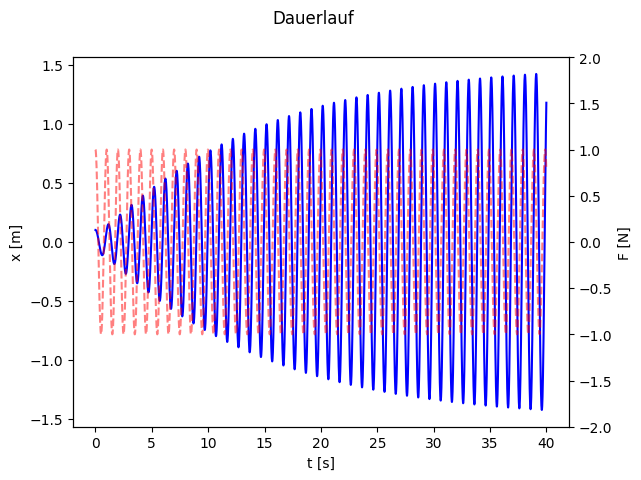

In [3]:
# Zustandsraumdarstellung fuer den Dauerlauf
def state_space_settled(z, t):
    [x, x_p] = z # Zustandsvektor --> Vom Studi auszufuellen
    z_p = [x_p, -2*delta*x_p - omega_0**2*x + b0*F_Hut*np.cos(Omega*t)] # Zustands-DGL --> Vom Studi auszufuellen
    return z_p

z_sol = odeint(state_space_settled, z0, t)

# Du brauchst die erste Zeile der Loesung zum Animieren. Das ist die Auslenkung x.
x = z_sol[:,0]

## Plotte die Erregung (normaler Cosinus) im gleichen Figure wie Loesung
fig, ax1 = plt.subplots();
ax2 = ax1.twinx();

ax1.set_ylabel('x [m]')
ax1.set_xlabel('t [s]')
ax1.plot(t, x, 'b');

ax2.set_ylim(-2, 2)
ax2.set_ylabel('F [N]') ## Hab die Amplitude fuer die Anregung auf 1 gesetzt, weil 1 ne glatte Zahl ist und weil wir nicht noch mehr Einfluesse wie
                           ## variable Amplitude mithineinbringen sollten. Eventuell schreibt man das in die Aufgabenstellung mit dazu. Wobei wir
                           ## wir natuerlich nur den Teil mit den Einfluessen hineinschreiben und nicht, dass 1 ne glatte Zahl ist LOL
ax2.plot(t, F_Hut*np.cos(Omega*t), 'r--', alpha=0.5);

fig.suptitle('Dauerlauf'); ## Betitelung

# Hochlauf

## Auslenkungsgraph (Hochlauf)

Text(0.5, 0.98, 'Hochlauf')

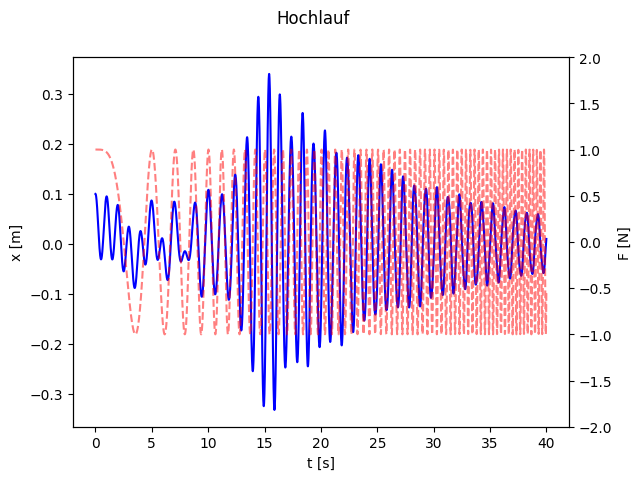

In [20]:
# Außerdem brauchen wir eine Winkelbeschleunigung (angular velocity), taufe sie alpha 
alpha = 0.5 # (Omega/100 bis Omega/5) in 20 gleichmaeßigen Schritten fuer Slider

# Wichtig: Fuer den Hochlauf muss Omega_vec genau so groß sein wie t. 
Omega_vec = np.linspace(0, 2*omega_0, t.size)
#Omega_vec = alpha*t

# Hier wuerde ich nichts vom Studi ausfuellen lassen. Ist eher unnoetig, weil es sehr aehnlich zum Dauerlauf ist.
def state_space_accelerated(z, t):
    [x, x_p] = z
    z_p = [x_p, -2*delta*x_p - omega_0**2*x + b0*F_Hut*np.cos(0.5*alpha*t**2)]
    return z_p

z_sol = odeint(state_space_accelerated, z0, t)

# Du brauchst die erste Zeile der Loesung zum Animieren. Das ist die Auslenkung x.
x = z_sol[:,0]

## Plotte hier auch die Erregung (hier allerdings ein Cosinus-Sweep, also ein Cosinus der immer schneller wird) ueber den Hochlauf Graphen
## LSD Trip
fig, ax1 = plt.subplots();
ax2 = ax1.twinx();

ax1.set_ylabel('x [m]')
ax1.set_xlabel('t [s]')
ax1.plot(t, x, 'b');

ax2.set_ylim(-2, 2)
ax2.set_ylabel('F [N]')
ax2.plot(t, F_Hut*np.cos(0.5*alpha*t**2), 'r--', alpha = 0.5);

fig.suptitle('Hochlauf') ## Betitelung

# Bode Diagramme

c:\Users\duong\VSCodeProjects\tm_digitalisierung\venv\Lib\site-packages\scipy\signal\_filter_design.py:187: RuntimeWarning: divide by zero encountered in divide
  h = polyval(b, s) / polyval(a, s)
c:\Users\duong\VSCodeProjects\tm_digitalisierung\venv\Lib\site-packages\scipy\signal\_filter_design.py:187: RuntimeWarning: invalid value encountered in divide
  h = polyval(b, s) / polyval(a, s)


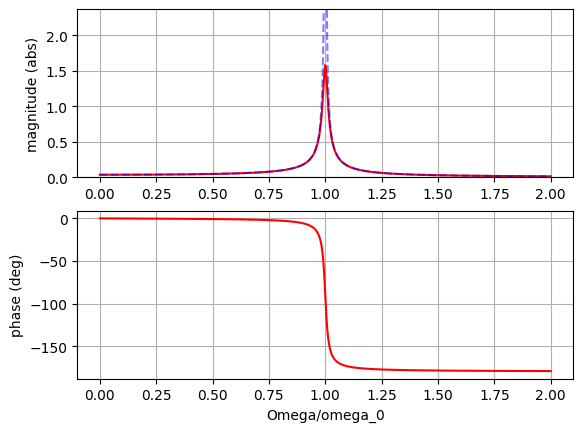

In [21]:
# Unter den Bode-Diagrammen verstehen wir die Kombination aus Amplituden- und Phasengang. 

# Definiere hier die Uebertragungsfunktion. Eigentlich sollten die Studis das ausfuellen, allerdings muessten die das mit Laplace-Transformation machen.
# Ich klaere das mit Eric ab.
num = np.array([b0]); #
den = np.array([1, 2*delta, omega_0**2]); #
G = signal.TransferFunction(num, den);

# bode-values
_, mag, phase = signal.bode(G, Omega_vec);
mag = 10**(mag/20) # Umrechnung von dB auf abs

G_undamped =signal.TransferFunction([b0], [1, 0, omega_0**2]);
_, mag_undamped, phase_undamped = signal.bode(G_undamped, Omega_vec);
mag_undamped = 10**(mag_undamped/20)
# Achtung: dieser Graph wird singulaer, wir sollten die y-Achse begrenzen. 
# Ich schlage vor wir begrenzen den maximalen Wert der y-Achse auf das 1.5*max(Omega_vec).
# Da der Amplitudengang immer > 0 ist, ist das natuerliche Minimum fuer die y-Achse 0.


plt.subplot(2,1,1)
plt.plot(Omega_vec/omega_0, mag, 'r');
plt.plot(Omega_vec/omega_0, mag_undamped, 'b--', alpha = 0.5); # Kannst du den Graph bisschen durchsichtiger machen? Der obere ist wichtiger
plt.ylim(top = 1.5*max(mag))
plt.ylim(bottom = 0)
plt.ylabel('magnitude (abs)')
plt.grid() ## Grid aktivieren

plt.subplot(2,1,2)
plt.plot(Omega_vec/omega_0, phase, 'r');
plt.ylabel('phase (deg)')
plt.xlabel('Omega/omega_0') # groß Omega / klein omega_0 , kannst du das Symbolisch machen?
plt.grid() ## Grid aktivieren

# Bericht

1. Die Begrenzung der Simulationsdauer koennte unter Umstaenden zu einigen Problemen fuehren:
- Es kann sein, dass wesentliche Effekte z.B. Der Durchlauf durch den Resonanzbereich nicht ersichtlich wird. Eine Anpasssung der Parameter kann dieses    Problem beheben, wobei aber die anderen Umstaende damit noch nicht behoben sind.
- Moechte man beim Dauerlauf (steady state) das Erreichen der Resonanzamplitude sichtbar machen, muss man innerhalb der kuerzeren Simulationsdauer sehr viele Schwingungen unterbringen, da sich das System einschwingen muss. Dies wird durch eine sehr steife Feder oder eine sehr geringe Masse erreicht. Dies bringt jedoch wiederum Nachteile mit sich. Zum Einen werden geringere Amplitudenverhaeltnisse erreicht (siehe Amplitudengang), was die Sichtbarkeit der Schwingungen in der Animation erschwert (es sei denn man passt Proportionen dort an). Zum Anderen wird im Hochlauf zwar der Durchlauf durch den Resonanzbereich qualitativ deutlich, quantitativ werden allerdings bei Weitem nicht mehr die Amplitudenwerte aus dem Dauerlauf erreicht, da das System keine Zeit hat sich einzuschwingen. Diese Diskrepanz ist umso staerker ausgepraegt, je hoeher die Eigenkreisfrequenz des Systems ist, denn dann ist auch die Winkelbeschleunigung in der Regel hoeher (schlechteres Einschwingen). 

2. Verbesserungsvorschlaege:
- Es gibt noch keinen Marker fuer die Bode-Diagramme, was daran liegt dass die Frequenzpunkte nicht zwingend zu den Auslenkungspunkten passen, was wiederum durch die unabhaengige Wahl von alpha durch den Nutzer zustande kommt. Ein ordentliches Mapping kann durch die Berechnung eines geeigneten Omega_vec = alpha*t  erreicht werden, wobei in diesem Fall bei geringen alpha und bei geringer Simulationsdauer moeglicherweise die Resonanz nicht durchlaufen, geschweige denn erreicht wird.